Testing the processing logic for a single file(Xray, center, azimuthal)

In [2]:
import sys
import os
# Get the current working directory (where the notebook is running)
current_dir = os.getcwd()
# Go up one level to project root (adjust based on your structure)
project_root = os.path.dirname(current_dir)
sys.path.insert(0, project_root)

In [3]:
from pathlib import Path
from src.processor.expdir_processor import DirectoryProcessor
from src.processor.processor_objects import XPSGroupProcessor
from src.io.tiff_SL import load_tiff_single
from src.masks.mask_class import precompute_center_masks, precompute_radial_masks, precompute_azimuthal_average_masks
from src.utils.xps_value_sort import group_tiff_files_with_info
import numpy as np

In [7]:
Result_folder = Path(r"C:\Users\ab177\Desktop\diffraction_results\test")
Expdata_folder = Path(r"E:\20251005\day2_61deg_longscan3\fist_AndorEMCCD")

background_path = Result_folder / "background.tiff"
background_data = load_tiff_single(background_path)
print(f"Loaded background from: {background_path}")

Loaded background from: C:\Users\ab177\Desktop\diffraction_results\test\background.tiff


In [32]:
ring_mask = precompute_center_masks(
    image_shape=(1440,1440),
    inner_radius=70, 
    outer_radius=120
)

# Initialize radial masks
radial_masks = precompute_radial_masks(
    image_shape=(1440,1440),
    radius=720, 
    num_bins=720
)

# Initialize azimuthal mask dictionary
azimuthal_mask_dict = precompute_azimuthal_average_masks(radial_masks)

In [ ]:
Preprocessor = DirectoryProcessor(
    result_directory= Result_folder,
    data_directory= Expdata_folder,
    xps_grouping_param= [],
    xray_removal_param= [15,0.7],
    center_fitting_param= [80,100,562,512],
    azimuthal_avg_param= [512,512],
    background_directory= "default",
    data_mask_directory= "default"
)
Preprocessor.initialize_bkg_and_datamask()
xps_value, filelist = Preprocessor.select_test_xps_group_numbered(group_size=200)[0]

2026-01-13 15:35:40,360 - INFO - Initializing background and data mask...
2026-01-13 15:35:40,379 - INFO - Loaded background from: C:\Users\ab177\Desktop\diffraction_results\test\background.tiff
2026-01-13 15:35:40,380 - INFO - Loaded data_mask from: C:\Users\ab177\Desktop\diffraction_results\test
2026-01-13 15:35:40,380 - INFO - Numbered test XPS group selection...



SELECT TEST XPS GROUP
 1. XPS 173.03500:  570 files
 2. XPS 173.18500:  570 files
 3. XPS 172.51000:  560 files
 4. XPS 172.31500:  550 files
 5. XPS 172.46500:  480 files
 6. XPS 172.36000:  470 files
 7. XPS 172.40500:  467 files
 8. XPS 172.49500:  460 files
 9. XPS 172.43500:  440 files
10. XPS 172.28500:  430 files
11. XPS 172.39000:  390 files
12. XPS 172.48000:  360 files
13. XPS 172.42000:  340 files
14. XPS 172.45000:  340 files
15. XPS 172.34500:  330 files
16. XPS 172.37375:  270 files
17. XPS 172.37500:  260 files
18. XPS 172.34375:  230 files
19. XPS 172.41875:  230 files
20. XPS 172.44875:  220 files
21. XPS 172.47875:  190 files
22. XPS 172.38875:  180 files
23. XPS 172.28375:  140 files
24. XPS 172.43375:  130 files
25. XPS 172.49375:  110 files
26. XPS 172.35875:   90 files
27. XPS 172.40375:   90 files
28. XPS 172.46375:   90 files
29. XPS 172.37125:   30 files
30. XPS 172.31375:   20 files
31. XPS 172.40250:   10 files
32. XPS 172.44750:   10 files
33. XPS 172.47625

In [10]:
Preprocessor.initialize_bkg_and_datamask()
TestProcessor = XPSGroupProcessor(
    background_data=background_data,
    data_mask_data=Preprocessor.data_mask_data,
    X_ray_config=[15, 0.7],  # [beam_threshold, expansion_threshold_ratio]
    center_config=[ring_mask, [920, 930]],  # [inner_radius, outer_radius, center_x, center_y]
    azimuthal_config=[radial_masks, azimuthal_mask_dict],  # [radius, num_bins]
    xps_value=xps_value, 
    filelist=filelist,
    resultdir=Result_folder
)
TestProcessor.precompute_xray_statistics()

2026-01-13 15:35:47,890 - INFO - Initializing background and data mask...
2026-01-13 15:35:47,903 - INFO - Loaded background from: C:\Users\ab177\Desktop\diffraction_results\test\background.tiff
2026-01-13 15:35:47,920 - INFO - Loaded data_mask from: C:\Users\ab177\Desktop\diffraction_results\test
2026-01-13 15:35:47,922 - INFO - Randomly sampled 50 files for X-ray statistics precomputation
2026-01-13 15:35:55,036 - INFO - X-ray statistics precomputation completed. Center region (40x40) excluded.


Plotting background used:

DEBUG PROCESSING: background.tiff
Under:C:\Users\ab177\Desktop\diffraction_results\test

1. ORIGINAL DATA:


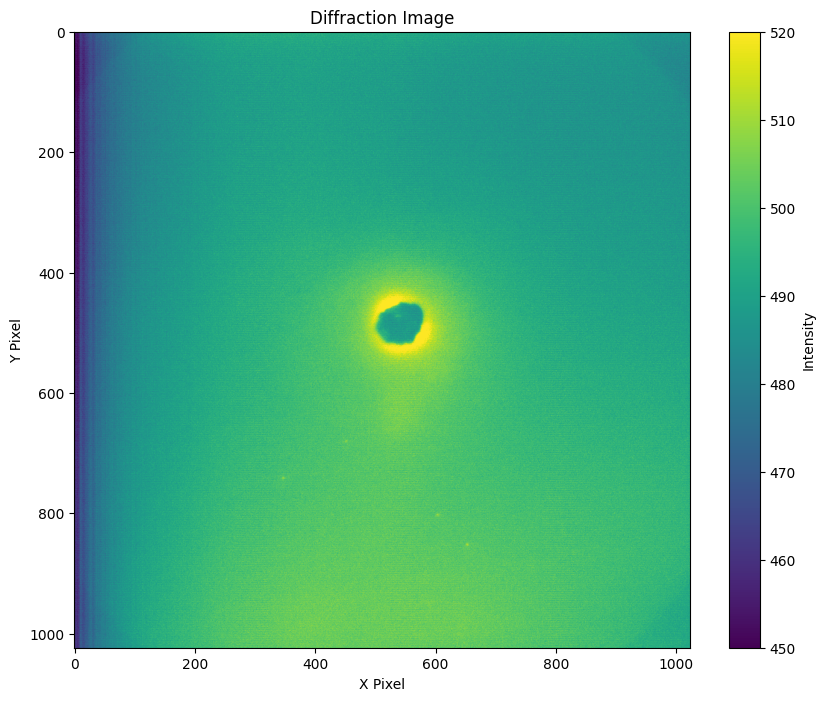


2. BACKGROUND REMOVAL:
After background removal:
NaN count: 0


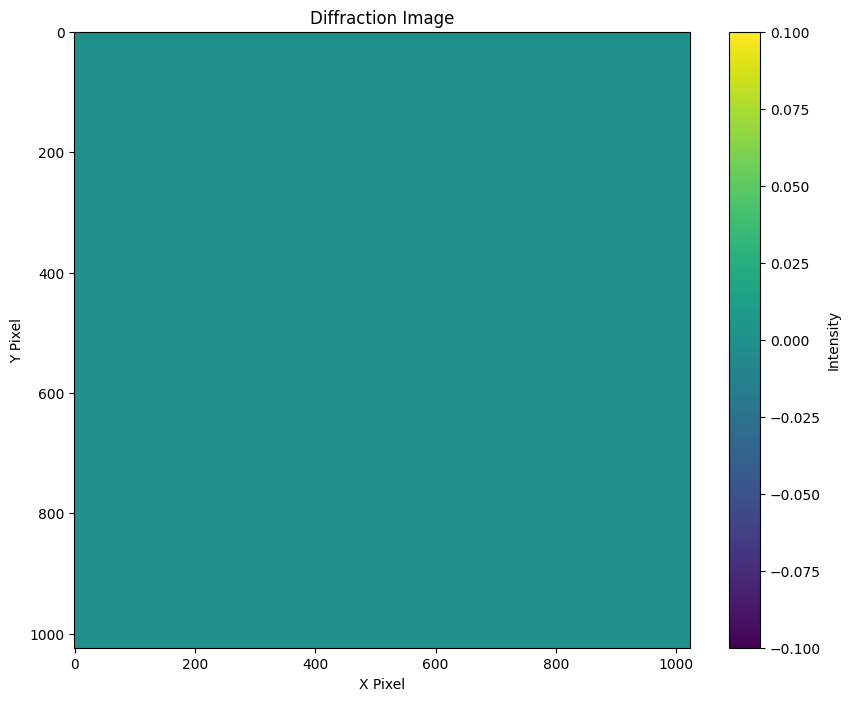


3. MASKING DATA:
After data masking:


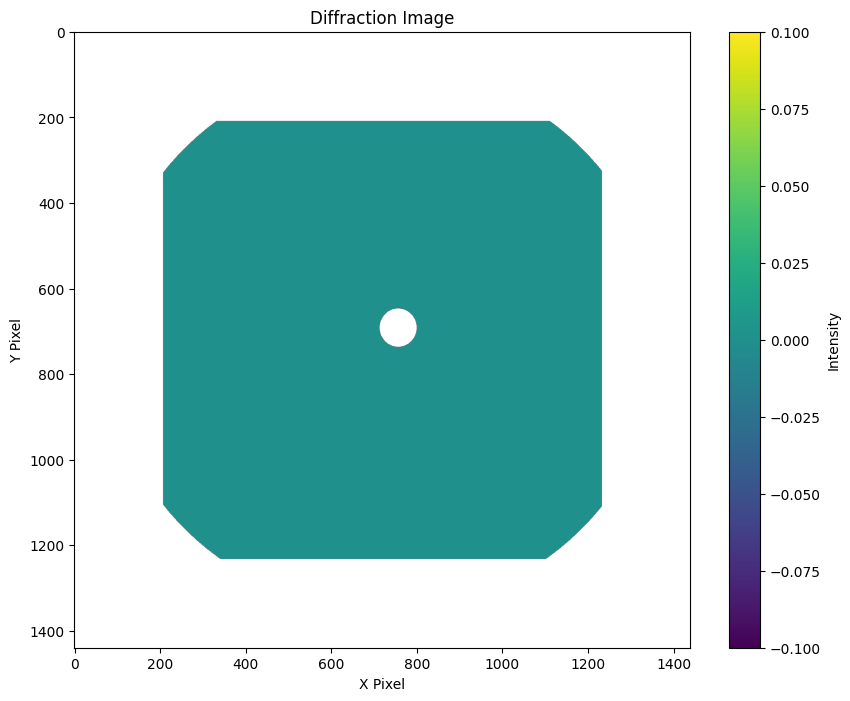


4. CENTER FINDING:
Found center: (712.00, 722.00)

5. AZIMUTHAL AVERAGE:
Radial profile range: [0.000, 0.000]
Non-NaN bins: 720/720


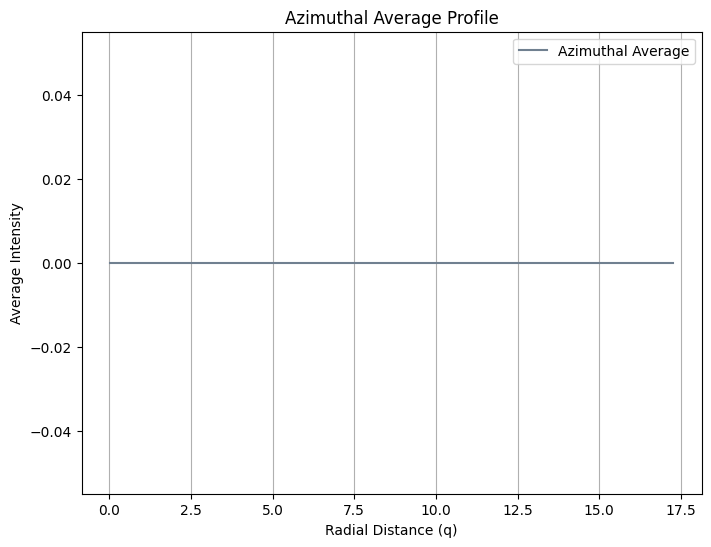


✓ SUCCESSFULLY PROCESSED: background.tiff


In [11]:
print('Plotting background used:')
TestProcessor.process_single_debug(r'C:\Users\ab177\Desktop\diffraction_results\test\background.tiff',450,520,0,0,1440)


DEBUG PROCESSING: AndorEMCCD-1418_xps173.035000_scan9_labtime13-51-30p806921.tiff
Under:E:\20251005\day2_61deg_longscan3\fist_AndorEMCCD

1. ORIGINAL DATA:


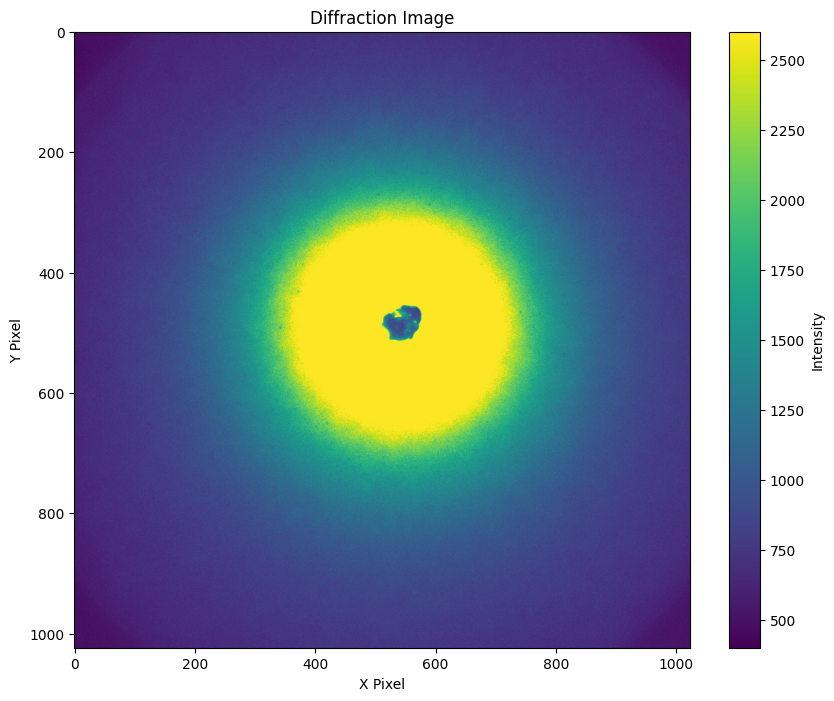


2. BACKGROUND REMOVAL:
After background removal:
NaN count: 0


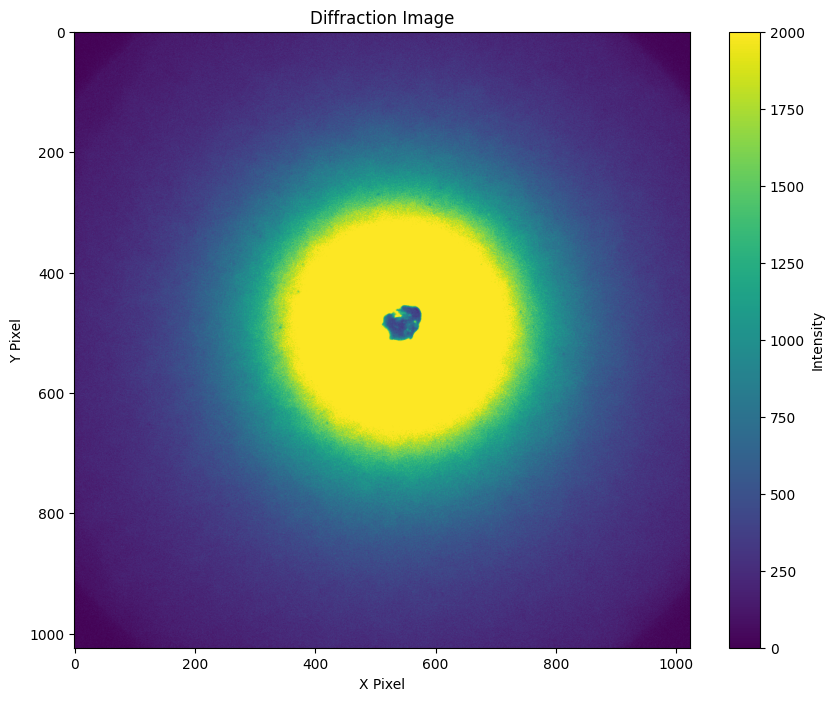


3. MASKING DATA:
After data masking:


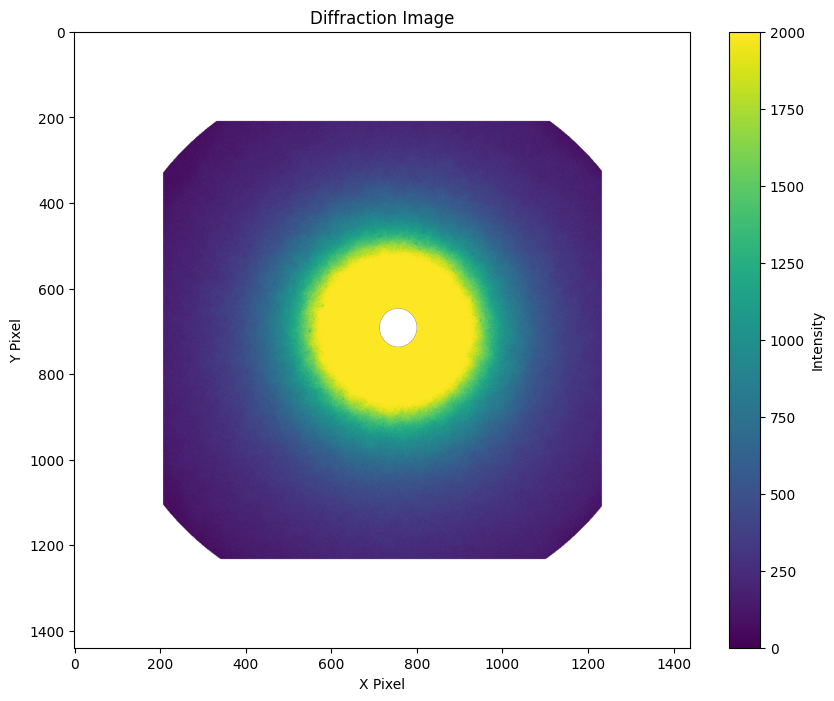


4. CENTER FINDING:
Found center: (542.78, 484.20)

5. AZIMUTHAL AVERAGE:
Radial profile range: [66.177, 15748.554]
Non-NaN bins: 644/720


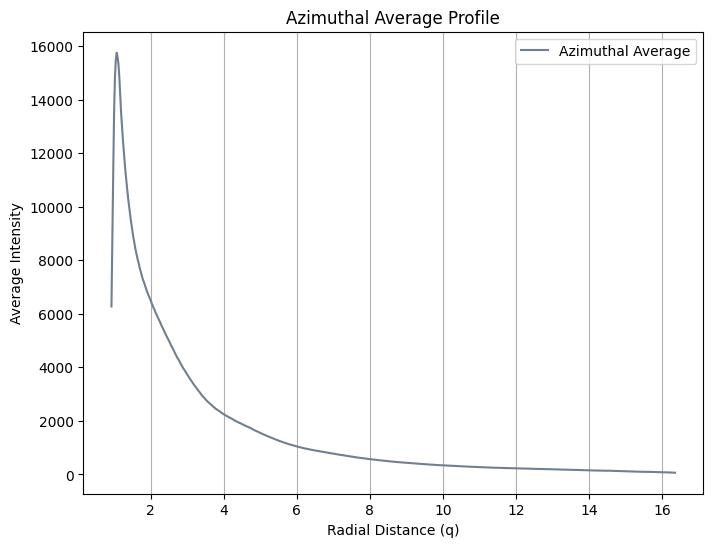


✓ SUCCESSFULLY PROCESSED: AndorEMCCD-1418_xps173.035000_scan9_labtime13-51-30p806921.tiff


In [34]:
TestProcessor.center_config[1] = [750,694]
TestProcessor.process_single_debug(filelist[10],400,2600,0,2000,1440)

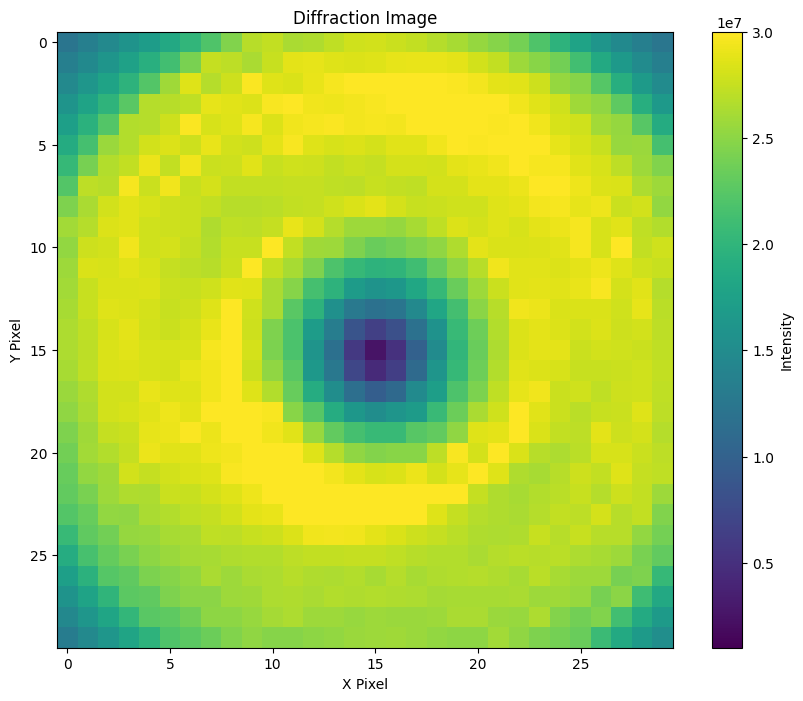

In [33]:
from src.processor.tiff_objects import EMCCDimage
from src.plots.quick_plot import plot_ndarray

test = EMCCDimage(load_tiff_single(filelist[10]))
test.remove_background_legacy(background_data)
test.apply_data_mask(Preprocessor.data_mask_data,1440)

std_array = []
for i in range(-15,15):
    std_line = []
    for j in range(-15,15):
        std = test.calculate_std_sum_with_masks([750+i*10,690+j*10],ring_mask)
        std_line += [std]
    std_array += [std_line]

plot_ndarray(std_array,1000000,30000000)

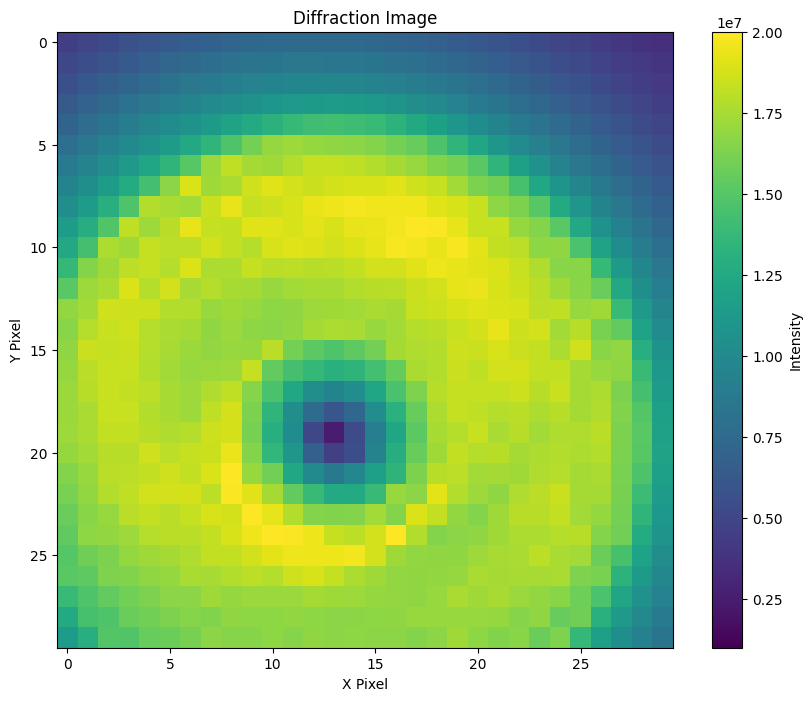

In [31]:
plot_ndarray(std_array,1000000,20000000)

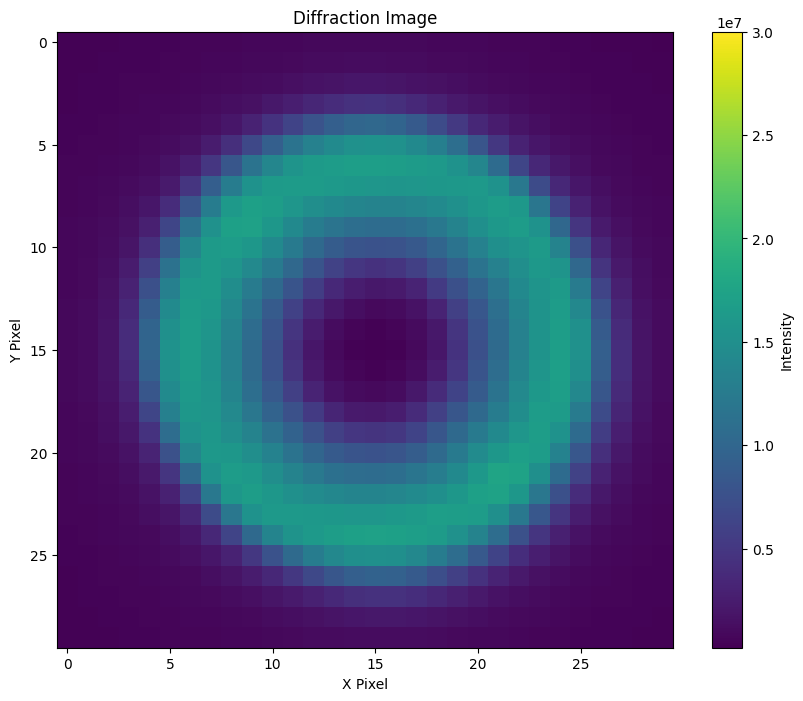

In [32]:
std_array = []
for i in range(-15,15):
    std_line = []
    for j in range(-15,15):
        std = test.calculate_std_sum_with_masks([920+i*10,925+j*10],ring_mask)
        std_line += [std]
    std_array += [std_line]

plot_ndarray(std_array,200000,30000000)

In [41]:
print(std_array[15][15])
print(std_array[14][14])
print(std_array[16][16])

175866.05693908708
646907.5381531706
635267.6840911658
